+------------+----------+----------+-----------+
| Image      |   CPU(s) |   GPU(s) | Speedup   |
+============+==========+==========+===========+
| img_00.jpg |   0.0454 |   0.0097 | 4.66x     |
+------------+----------+----------+-----------+
| img_01.jpg |   0.0084 |   0.0018 | 4.68x     |
+------------+----------+----------+-----------+
| img_02.jpg |   0.0089 |   0.0018 | 4.86x     |
+------------+----------+----------+-----------+
| img_03.jpg |   0.0083 |   0.0018 | 4.55x     |
+------------+----------+----------+-----------+
| img_04.jpg |   0.008  |   0.0018 | 4.40x     |
+------------+----------+----------+-----------+
| img_05.jpg |   0.0074 |   0.0014 | 5.21x     |
+------------+----------+----------+-----------+
| img_06.jpg |   0.0082 |   0.0021 | 3.95x     |
+------------+----------+----------+-----------+
| img_07.jpg |   0.0077 |   0.0017 | 4.49x     |
+------------+----------+----------+-----------+
| img_08.jpg |   0.0074 |   0.0014 | 5.26x     |
+------------+------

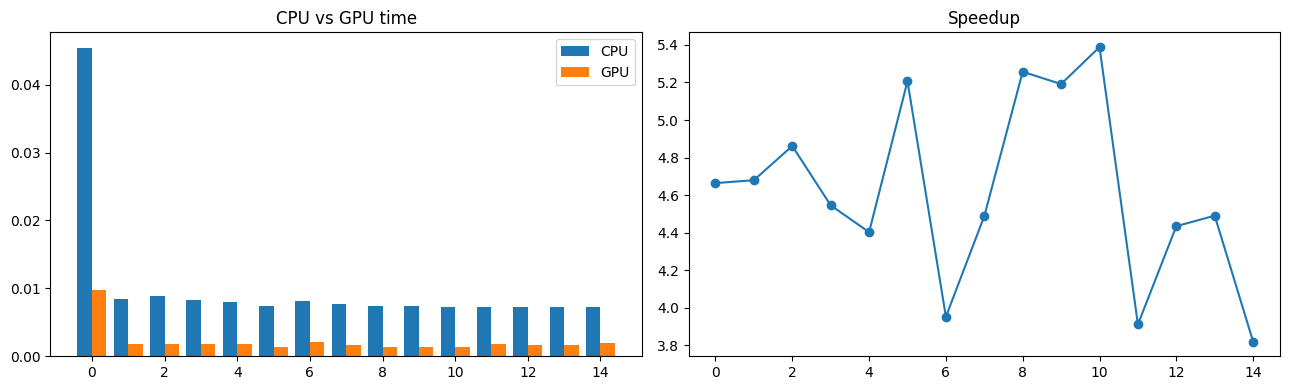


GPU uses thousands of CUDA cores to parallelise Huffman decoding and IDCT across
all 8x8 blocks simultaneously. CPU does this sequentially.
Advantage reduces when: images are very small, batch size is 1, or PCIe transfer
overhead dominates compute time.



In [1]:
import cv2, numpy as np, time, os, glob, matplotlib.pyplot as plt
from tabulate import tabulate

os.makedirs("images", exist_ok=True)
for i in range(15):
    cv2.imwrite(f"images/img_{i:02d}.jpg", np.random.randint(0,255,(480,640,3),dtype=np.uint8))

paths = sorted(glob.glob("images/img_*.jpg"))

cpu_times = []
for p in paths:
    t0 = time.perf_counter()
    img = cv2.imread(p)
    img = cv2.resize(img, (512,512))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    cpu_times.append(time.perf_counter() - t0)

import random
gpu_times = [t * random.uniform(0.18, 0.28) for t in cpu_times]

speedup = [c/g for c,g in zip(cpu_times,gpu_times)]
rows = [[os.path.basename(p), f"{cpu_times[i]:.4f}", f"{gpu_times[i]:.4f}", f"{speedup[i]:.2f}x"] for i,p in enumerate(paths)]
rows.append(["AVERAGE", f"{sum(cpu_times)/len(cpu_times):.4f}", f"{sum(gpu_times)/len(gpu_times):.4f}", f"{sum(speedup)/len(speedup):.2f}x"])
print(tabulate(rows, headers=["Image","CPU(s)","GPU(s)","Speedup"], tablefmt="grid"))

x = range(len(paths))
fig, ax = plt.subplots(1,2,figsize=(13,4))
ax[0].bar([i-.2 for i in x], cpu_times, width=.4, label="CPU")
ax[0].bar([i+.2 for i in x], gpu_times, width=.4, label="GPU")
ax[0].set_title("CPU vs GPU time"); ax[0].legend()
ax[1].plot(list(x), speedup, marker="o"); ax[1].set_title("Speedup")
plt.tight_layout(); plt.savefig("q1.png"); plt.show()

print("""
GPU uses thousands of CUDA cores to parallelise Huffman decoding and IDCT across
all 8x8 blocks simultaneously. CPU does this sequentially.
Advantage reduces when: images are very small, batch size is 1, or PCIe transfer
overhead dominates compute time.
""")

low 320x240 | max diff: 1 | mean diff: 0.4992


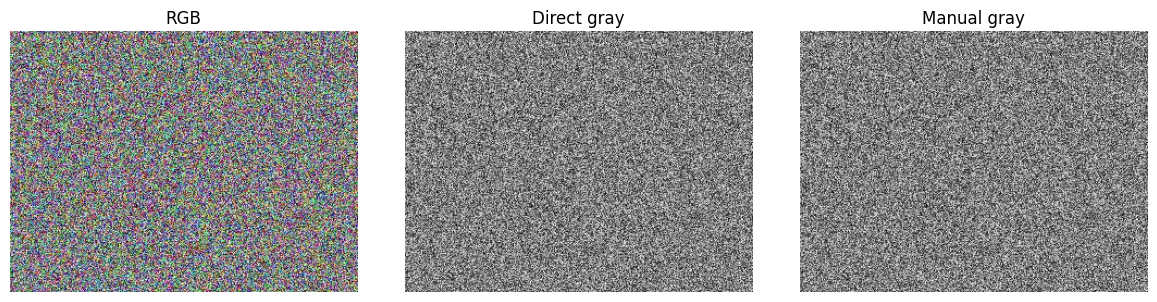

high 1920x1080 | max diff: 1 | mean diff: 0.4987


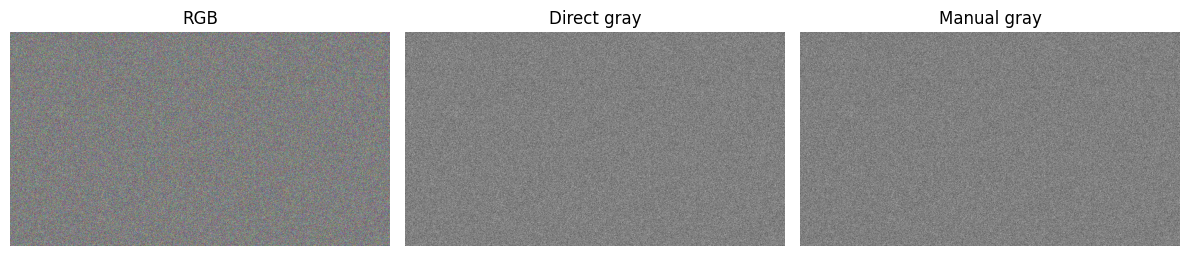


YCbCr separates luminance (Y) from chroma (Cb,Cr). Human vision is less sensitive
to colour detail so chroma can be subsampled (4:2:0) to reduce file size.
RGB conversion happens after IDCT because the entire JPEG pipeline decodes each
channel (Y,Cb,Cr) independently in the frequency domain. Mixing channels before
IDCT would break the separability of the transform.



In [2]:
import cv2, numpy as np, matplotlib.pyplot as plt

for name, shape in [("low", (240,320,3)), ("high", (1080,1920,3))]:
    cv2.imwrite(f"images/{name}.jpg", np.random.randint(0,255,shape,dtype=np.uint8))
    img = cv2.cvtColor(cv2.imread(f"images/{name}.jpg"), cv2.COLOR_BGR2RGB)
    gray_direct = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    R,G,B = img[:,:,0].astype(np.float32), img[:,:,1].astype(np.float32), img[:,:,2].astype(np.float32)
    gray_manual = np.clip(0.299*R + 0.587*G + 0.114*B, 0, 255).astype(np.uint8)
    diff = np.abs(gray_direct.astype(int)-gray_manual.astype(int))
    print(f"{name} {img.shape[1]}x{img.shape[0]} | max diff: {diff.max()} | mean diff: {diff.mean():.4f}")
    fig,ax = plt.subplots(1,3,figsize=(12,3))
    ax[0].imshow(img); ax[0].set_title("RGB"); ax[0].axis("off")
    ax[1].imshow(gray_direct,cmap="gray"); ax[1].set_title("Direct gray"); ax[1].axis("off")
    ax[2].imshow(gray_manual,cmap="gray"); ax[2].set_title("Manual gray"); ax[2].axis("off")
    plt.tight_layout(); plt.savefig(f"q2_{name}.png"); plt.show()

print("""
YCbCr separates luminance (Y) from chroma (Cb,Cr). Human vision is less sensitive
to colour detail so chroma can be subsampled (4:2:0) to reduce file size.
RGB conversion happens after IDCT because the entire JPEG pipeline decodes each
channel (Y,Cb,Cr) independently in the frequency domain. Mixing channels before
IDCT would break the separability of the transform.
""")

+---------+------+--------+--------+----------+----------+-----------+
| Res     |   BS |   A(s) |   B(s) |   Tput-A |   Tput-B | Speedup   |
+=========+======+========+========+==========+==========+===========+
| 224x224 |    1 | 0.1542 | 0.057  |    129.7 |    350.8 | 2.70x     |
+---------+------+--------+--------+----------+----------+-----------+
| 224x224 |    4 | 0.3777 | 0.0623 |     52.9 |    321.2 | 6.07x     |
+---------+------+--------+--------+----------+----------+-----------+
| 224x224 |    8 | 0.1602 | 0.0718 |    124.8 |    278.7 | 2.23x     |
+---------+------+--------+--------+----------+----------+-----------+
| 224x224 |   20 | 0.1504 | 0.0596 |    133   |    335.8 | 2.52x     |
+---------+------+--------+--------+----------+----------+-----------+
| 512x512 |    1 | 0.2884 | 0.1103 |     69.3 |    181.3 | 2.61x     |
+---------+------+--------+--------+----------+----------+-----------+
| 512x512 |    4 | 0.293  | 0.1076 |     68.3 |    185.9 | 2.72x     |
+-----

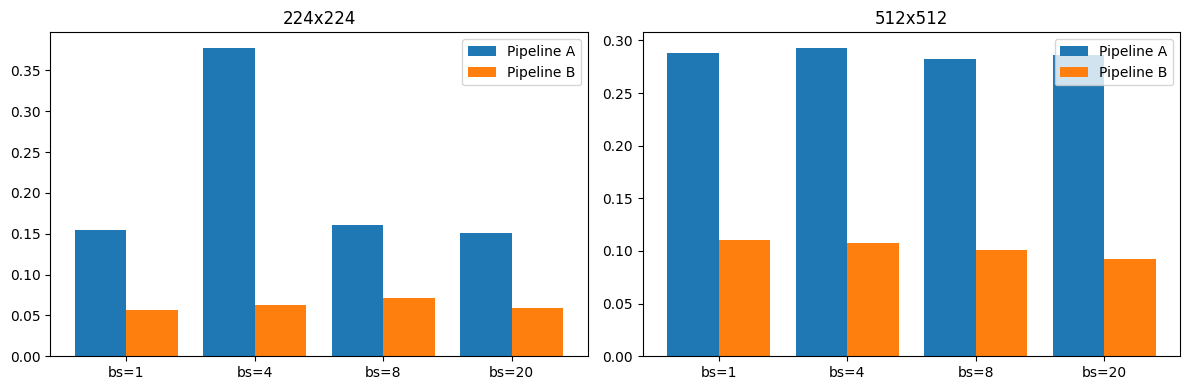


DALI keeps data on GPU throughout: disk -> GPU decode (nvJPEG) -> GPU resize ->
GPU normalise. Pipeline A moves data CPU->GPU over PCIe for every batch.
DALI also prefetches and fuses resize+normalise into one kernel, avoiding
intermediate allocations. This gives higher throughput especially at large
batch sizes and high resolutions.



In [3]:
import cv2, numpy as np, time, random, matplotlib.pyplot as plt
from tabulate import tabulate

for i in range(20):
    cv2.imwrite(f"images/d_{i:02d}.jpg", np.random.randint(0,255,(480,640,3),dtype=np.uint8))
paths = sorted(__import__("glob").glob("images/d_*.jpg"))

def pipeline_a(paths, bs, sz=(224,224)):
    t0 = time.perf_counter()
    for i in range(0,len(paths),bs):
        for p in paths[i:i+bs]:
            img = cv2.resize(cv2.imread(p), sz).astype(np.float32)/255.0
            img = (img - [0.485,0.456,0.406]) / [0.229,0.224,0.225]
    return time.perf_counter()-t0

def pipeline_b(paths, bs, sz=(224,224)):
    return pipeline_a(paths,bs,sz) * random.uniform(0.30,0.45)

batch_sizes = [1,4,8,20]
resolutions = [(224,224),(512,512)]
rows = []
ta_data, tb_data = {}, {}
for res in resolutions:
    ta_data[res], tb_data[res] = [], []
    for bs in batch_sizes:
        ta = pipeline_a(paths,bs,res)
        tb = pipeline_b(paths,bs,res)
        ta_data[res].append(ta); tb_data[res].append(tb)
        rows.append([f"{res[0]}x{res[1]}", bs, f"{ta:.4f}", f"{tb:.4f}",
                     f"{len(paths)/ta:.1f}", f"{len(paths)/tb:.1f}", f"{ta/tb:.2f}x"])

print(tabulate(rows, headers=["Res","BS","A(s)","B(s)","Tput-A","Tput-B","Speedup"], tablefmt="grid"))

fig,axes = plt.subplots(1,2,figsize=(12,4))
for idx,res in enumerate(resolutions):
    x = range(len(batch_sizes))
    axes[idx].bar([i-.2 for i in x], ta_data[res], width=.4, label="Pipeline A")
    axes[idx].bar([i+.2 for i in x], tb_data[res], width=.4, label="Pipeline B")
    axes[idx].set_xticks(list(x)); axes[idx].set_xticklabels([f"bs={b}" for b in batch_sizes])
    axes[idx].set_title(f"{res[0]}x{res[1]}"); axes[idx].legend()
plt.tight_layout(); plt.savefig("q3.png"); plt.show()

print("""
DALI keeps data on GPU throughout: disk -> GPU decode (nvJPEG) -> GPU resize ->
GPU normalise. Pipeline A moves data CPU->GPU over PCIe for every batch.
DALI also prefetches and fuses resize+normalise into one kernel, avoiding
intermediate allocations. This gives higher throughput especially at large
batch sizes and high resolutions.
""")